# 12장. 로그는 쌓고 있는데 왜 전환율을 못 구해요?

가상의 콘텐츠 앱 로그 30일치를 놓고 배포 뒤에 조용히 깨진 로그를 찾는 모니터링을 처음부터 끝까지 돌려 봅니다. 8월 25일 배포에서 생긴 사고 5종이 `generate_data.py`에 심어져 있고, 다섯 모두 표준 문턱(±60%, 최소 50건)으로 잡힙니다.

- **12.7.2.** 원본 로그에서 일별 이벤트 마트·프로퍼티 채움률 마트를 DuckDB로 만듭니다.
- **12.7.3.** 기준일(D-2)과 일주일 전(D-9)의 이벤트 수를 비교해 ±60%·최소 50건 문턱을 넘는 이벤트를 찾고 30일 추세를 그립니다.
- **12.7.4.** (이벤트, 프로퍼티)별 not-null 비율이 60% 넘게 떨어진 것을 찾습니다.
- **12.7.5.** 결과를 슬랙 메시지 형식 텍스트로 조립합니다 (전송은 주석 한 줄).

## 12.7.1. 실습용 데이터 준비

In [ ]:
%pip install -q -r requirements.txt   # 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)

`python generate_data.py`로 `data/` 아래 CSV 세 개를 먼저 만들어 둡니다. 기준일은 8월 28일(D-2), 비교일은 그 일주일 전인 8월 21일(D-9)이고, 배포는 8월 25일입니다.

먼저 노트북 전체에서 재사용할 DuckDB 연결을 만들고, 로그 파일과 택소노미 프로퍼티 문서를 테이블로 올린 뒤 로그 앞 네 행을 확인합니다. 실습의 기준일(`BASIS_DATE`)과 배포일(`RELEASE_DATE`)도 이 셀에서 상수로 정해 둡니다.


In [2]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

BASIS_DATE, RELEASE_DATE = "2026-08-28", "2026-08-25"
con = duckdb.connect()   # 노트북 전체에서 재사용
con.execute("CREATE TABLE event_log AS "
            "SELECT * FROM read_csv_auto('data/event_log.csv')")
con.execute("CREATE TABLE taxonomy_properties AS SELECT * FROM "
            "read_csv_auto('data/taxonomy_properties.csv', all_varchar=true)")
con.execute("SELECT * FROM event_log LIMIT 4").df()

,event_time,user_id,platform,app_version,event_name,screen_name,properties
0,2026-08-01 00:02:00,u01076,Android,3.4.1,page_view_home,home,{}
1,2026-08-01 00:02:00,u01076,Android,3.4.1,view_main_banner,home,"{""banner_id"": ""b5""}"
2,2026-08-01 00:02:00,u01076,Android,3.4.1,view_content_card,home,"{""content_id"": ""c266"", ""content_type"": ""articl..."
3,2026-08-01 00:02:00,u01076,Android,3.4.1,view_content_card,home,"{""content_id"": ""c384"", ""content_type"": ""video""..."


---
## 12.7.2. 일별 마트 만들기 — 모니터링은 원본이 아니라 마트 위에서 돈다

첫 번째 마트는 날짜·플랫폼·이벤트별 건수와 유저 수입니다.

In [3]:
sql_mart_event_daily = """
SELECT CAST(event_time AS DATE) AS event_date,
       platform,
       event_name,
       COUNT(*)                AS event_cnt,
       COUNT(DISTINCT user_id) AS user_cnt
FROM event_log
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
"""
con.execute("CREATE TABLE mart_event_daily AS " + sql_mart_event_daily)
con.execute("""SELECT * FROM mart_event_daily
               WHERE event_date = DATE '2026-08-21'
                 AND event_name IN ('page_view_home', 'view_content_card',
                                    'tap_content_card')
               ORDER BY event_name, platform""").df()

,event_date,platform,event_name,event_cnt,user_cnt
0,2026-08-21,Android,page_view_home,297,297
1,2026-08-21,iOS,page_view_home,378,378
2,2026-08-21,Android,tap_content_card,251,172
3,2026-08-21,iOS,tap_content_card,330,230
4,2026-08-21,Android,view_content_card,1048,297
5,2026-08-21,iOS,view_content_card,1336,378


두 번째 마트는 프로퍼티 채움률입니다. 택소노미 문서의 '붙는 이벤트' 열을 풀어 (이벤트, 프로퍼티) 쌍을 만들고, 로그 JSON에서 그 키가 비어 있지 않은 비율을 셉니다.

In [4]:
sql_mart_event_param_daily = """
WITH keys AS (
  SELECT property_name AS param_key,
         unnest(string_split(events, '|')) AS event_name
  FROM taxonomy_properties
  WHERE scope = 'event' AND events <> ''
),
vals AS (
  SELECT CAST(l.event_time AS DATE) AS event_date,
         l.platform, l.event_name, k.param_key,
         json_extract_string(l.properties, '$.' || k.param_key) AS val
  FROM event_log l
  JOIN keys k USING (event_name)
)
SELECT event_date, platform, event_name, param_key,
       COUNT(*) AS event_cnt,
       COUNT(val) AS not_null_event_cnt,
       COUNT(val) * 1.0 / COUNT(*) AS not_null_ratio
FROM vals
GROUP BY 1, 2, 3, 4
ORDER BY 1, 2, 3, 4
"""
con.execute("CREATE TABLE mart_event_param_daily AS "
            + sql_mart_event_param_daily)

마트가 제대로 만들어졌는지 콘텐츠 상세 화면 이벤트만 골라 확인해 봅니다.

In [5]:
con.execute("""SELECT * FROM mart_event_param_daily
               WHERE event_date = DATE '2026-08-21'
                 AND event_name = 'page_view_content_detail'
               ORDER BY platform, param_key""").df()

,event_date,platform,event_name,param_key,event_cnt,not_null_event_cnt,not_null_ratio
0,2026-08-21,Android,page_view_content_detail,content_id,251,251,1.0
1,2026-08-21,Android,page_view_content_detail,content_type,251,251,1.0
2,2026-08-21,iOS,page_view_content_detail,content_id,330,330,1.0
3,2026-08-21,iOS,page_view_content_detail,content_type,330,330,1.0


In [6]:
n = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
     for t in ["event_log", "mart_event_daily", "mart_event_param_daily"]}
print(f"원본 {n['event_log']:,}행 → 이벤트 마트 {n['mart_event_daily']:,}행 "
      f"· 프로퍼티 마트 {n['mart_event_param_daily']:,}행")

원본 172,458행 → 이벤트 마트 1,426행 · 프로퍼티 마트 1,486행


---
## 12.7.3. 이벤트 수 이상 감지 — 일주일 전과 비교하기

기준일과 일주일 전을 이벤트·플랫폼으로 조인하고, 변화율의 절댓값이 60%를 넘으면서 어느 한쪽 건수가 50건을 넘는 것만 남깁니다. 기준일·문턱·최소 건수는 쿼리 맨 위 `params`에 있습니다.

In [7]:
sql_event_count_anomaly = """
WITH params AS (SELECT DATE '2026-08-28' AS basis_date, 0.6 AS threshold,
                50 AS min_cnt),
d1 AS (SELECT m.* FROM mart_event_daily m, params p
       WHERE m.event_date = p.basis_date),
d8 AS (SELECT m.* FROM mart_event_daily m, params p
       WHERE m.event_date = p.basis_date - INTERVAL 7 DAY),
diff AS (
  SELECT coalesce(d1.event_cnt, 0) * 1.0 / d8.event_cnt - 1 AS diff_ratio,
         d8.platform, d8.event_name,
         d8.event_cnt AS prev_event_cnt,
         coalesce(d1.event_cnt, 0) AS event_cnt
  FROM d8 LEFT JOIN d1 USING (event_name, platform)
)
SELECT diff.* FROM diff, params p
WHERE (prev_event_cnt > p.min_cnt OR event_cnt > p.min_cnt)
  AND abs(diff_ratio) > p.threshold
ORDER BY diff_ratio
"""
ev = con.execute(sql_event_count_anomaly).df()
ev

,diff_ratio,platform,event_name,prev_event_cnt,event_cnt
0,-1.000000,Android,system_subscription_renewed,83,0
1,-1.000000,iOS,system_subscription_renewed,76,0
2,-0.687879,iOS,tap_content_card,330,103
3,-0.646465,Android,page_view_home,297,105
4,1.206107,Android,view_content_card,1048,2312


시각화로 한 번 더 확인합니다. 규모가 다른 다섯 이벤트를 한 그림에 놓기 위해 배포 전 평균을 100으로 놓은 지수로 그리면, 배포일에 꺾이는 모양이 그대로 보입니다.

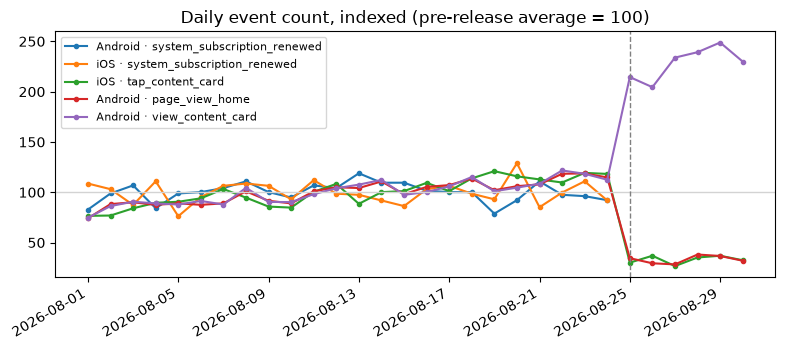

In [8]:
trend = con.execute("SELECT * FROM mart_event_daily ORDER BY 1").df()
fig, ax = plt.subplots(figsize=(8, 3.6))
for r in ev.itertuples():
    t = trend[(trend.platform == r.platform)
              & (trend.event_name == r.event_name)]
    base = t[t.event_date < pd.Timestamp(RELEASE_DATE)].event_cnt.mean()
    ax.plot(t.event_date, t.event_cnt / base * 100, marker="o", ms=3,
            label=f"{r.platform} · {r.event_name}")
ax.axhline(100, color="lightgray", lw=1)
ax.axvline(pd.Timestamp(RELEASE_DATE), color="gray", ls="--", lw=1)
ax.set_title("Daily event count, indexed (pre-release average = 100)")
ax.legend(fontsize=8); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig("img/event_trend.png", dpi=150)

---
## 12.7.4. 프로퍼티 누락 이상 감지 — 이벤트는 오는데 값이 비는 사고

프로퍼티 마트에서 같은 두 날짜를 꺼내 (이벤트, 프로퍼티)로 조인하고, 채움률이 60% 넘게 떨어진 것만 남깁니다. 올라가는 쪽은 보지 않습니다. 기준일에 이벤트가 온 쌍만 보고, 아예 안 온 이벤트는 앞 단계 몫으로 둡니다.

In [9]:
sql_param_null_anomaly = """
WITH params AS (SELECT DATE '2026-08-28' AS basis_date, 0.6 AS threshold,
                50 AS min_cnt),
d1 AS (SELECT m.* FROM mart_event_param_daily m, params p
       WHERE m.event_date = p.basis_date),
d8 AS (SELECT m.* FROM mart_event_param_daily m, params p
       WHERE m.event_date = p.basis_date - INTERVAL 7 DAY),
diff AS (
  SELECT coalesce(d1.not_null_ratio, 0) / d8.not_null_ratio - 1
           AS null_ratio_diff,
         d8.platform, d8.event_name, d8.param_key,
         d8.not_null_ratio AS prev_not_null_ratio,
         coalesce(d1.not_null_ratio, 0) AS not_null_ratio,
         coalesce(d1.event_cnt, 0) AS event_cnt
  FROM d8 LEFT JOIN d1 USING (event_name, platform, param_key)
)
SELECT diff.* FROM diff, params p
WHERE event_cnt > p.min_cnt
  AND prev_not_null_ratio > 0
  AND null_ratio_diff < -p.threshold
ORDER BY null_ratio_diff
"""
pr = con.execute(sql_param_null_anomaly).df()
pr

,null_ratio_diff,platform,event_name,param_key,prev_not_null_ratio,not_null_ratio,event_cnt
0,-0.714286,iOS,page_view_content_detail,content_id,1.0,0.285714,350


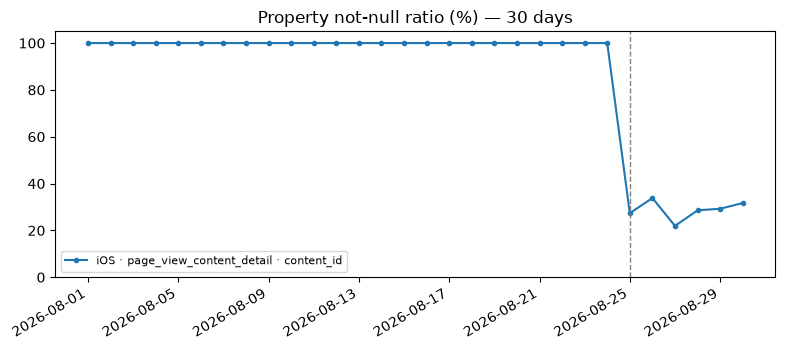

In [10]:
ptrend = con.execute("SELECT * FROM mart_event_param_daily ORDER BY 1").df()
fig, ax = plt.subplots(figsize=(8, 3.6))
for r in pr.itertuples():
    t = ptrend[(ptrend.platform == r.platform)
               & (ptrend.event_name == r.event_name)
               & (ptrend.param_key == r.param_key)]
    ax.plot(t.event_date, t.not_null_ratio * 100, marker="o", ms=3,
            label=f"{r.platform} · {r.event_name} · {r.param_key}")
ax.axvline(pd.Timestamp(RELEASE_DATE), color="gray", ls="--", lw=1)
ax.set_ylim(0, 105); ax.set_title("Property not-null ratio (%) — 30 days")
ax.legend(fontsize=8); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig("img/param_trend.png", dpi=150)

---
## 12.7.5. 리포트 만들기 — 슬랙에 보낼 여섯 줄

감소한 이벤트, 증가한 이벤트, 채움률이 떨어진 프로퍼티를 각각 한 줄씩, 일주일 전 숫자와 기준일 숫자와 변화율을 붙입니다. 이상이 없으면 없다고 한 줄 보냅니다.

In [11]:
def fmt_pct(x):
    return f"{x * 100:+.1f}%"

def event_line(r):
    return (f" • {r.platform} `{r.event_name}` | {r.prev_event_cnt:,} → "
            f"{r.event_cnt:,} ({fmt_pct(r.diff_ratio)})")

def param_line(r):
    return (f" • {r.platform} `{r.event_name}`: `{r.param_key}` | "
            f"{r.prev_not_null_ratio:.1%} → {r.not_null_ratio:.1%} "
            f"({fmt_pct(r.null_ratio_diff)})")

세 묶음을 제목과 함께 차례로 붙이면 메시지가 완성됩니다. 마지막 주석 한 줄을 우리 채널의 웹훅으로 바꾸면 그대로 발송됩니다.

In [12]:
def build_report(ev, pr, basis_date):
    lines = [f"🚨 로그 이상 감지 리포트 — {basis_date} "
             "(일주일 전 대비, ±60%, 최소 50건)"]
    sections = [("📉 감소한 이벤트", ev[ev.diff_ratio < 0], event_line),
                ("📈 증가한 이벤트", ev[ev.diff_ratio > 0], event_line),
                ("🕳️ 채움률이 떨어진 프로퍼티", pr, param_line)]
    for title, df, fmt in sections:
        if len(df):
            lines += [title] + [fmt(r) for r in df.itertuples()]
    if len(ev) == 0 and len(pr) == 0:
        lines.append("✅ 이상 없음")
    return "\n".join(lines)

report = build_report(ev, pr, BASIS_DATE)
print(report)
# 우리 슬랙 웹훅으로 바꾸면 끝:
# requests.post(WEBHOOK_URL, json={"text": report})

🚨 로그 이상 감지 리포트 — 2026-08-28 (일주일 전 대비, ±60%, 최소 50건)
📉 감소한 이벤트
 • Android `system_subscription_renewed` | 83 → 0 (-100.0%)
 • iOS `system_subscription_renewed` | 76 → 0 (-100.0%)
 • iOS `tap_content_card` | 330 → 103 (-68.8%)
 • Android `page_view_home` | 297 → 105 (-64.6%)
📈 증가한 이벤트
 • Android `view_content_card` | 1,048 → 2,312 (+120.6%)
🕳️ 채움률이 떨어진 프로퍼티
 • iOS `page_view_content_detail`: `content_id` | 100.0% → 28.6% (-71.4%)


## 마무리

마지막 주석 한 줄을 우리 채널의 웹훅으로 바꾸고 이 노트북을 주 2회 스케줄에 올리면 모니터링 루틴이 완성됩니다. 우리 서비스에 일별 이벤트 마트가 이미 있다면 12.7.3·12.7.4 쿼리의 테이블 이름만 바꾸면 그대로 돌아갑니다. 기준일·문턱·최소 건수는 `params` 한 곳에 있으니 우리 서비스 규모에 맞게 바꿔 보세요.